## Task 1

---

In [12]:
import pandas as pd
import numpy as np


In [13]:
goldman_df = pd.read_csv("goldman_sachs - goldman_sachs.csv")
print(goldman_df)


     TransactionID CustomerID AccountID AccountType TransactionType  \
0               33   CUST6549  ACC12334      Credit      Withdrawal   
1              177   CUST2942  ACC52650      Credit      Withdrawal   
2              178   CUST6776  ACC45101     Current         Deposit   
3              173   CUST2539  ACC88252     Current      Withdrawal   
4               67   CUST2626  ACC21878     Savings      Withdrawal   
..             ...        ...       ...         ...             ...   
795             11   CUST8461  ACC60432     Current      Withdrawal   
796             44   CUST1121  ACC41829      Credit      Withdrawal   
797            160   CUST3059  ACC28292     Current         Payment   
798             37   CUST1042  ACC28295     Current         Payment   
799            101   CUST2464  ACC53865        Loan         Deposit   

             Product    Firm   Region    Manager TransactionDate  \
0    Savings Account  Firm C  Central  Manager 1      21-10-2023   
1          

In [14]:
# Initial data inspection
# Checking structure, data types, and missing values
goldman_df.head()
goldman_df.info()
goldman_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [15]:
# Clean financial columns
# Removing currency symbols and special characters
# Converting values to numeric format
financial_cols = ["TransactionAmount", "AccountBalance"]

for col in financial_cols:
    goldman_df[col] = (
        goldman_df[col]
        .astype(str)
        .str.replace(r"[^0-9.-]", "", regex=True)
    )
    goldman_df[col] = pd.to_numeric(goldman_df[col], errors="coerce")


In [16]:
##Task 1: Data Cleaning and Formatting
# Remove/treat any special characters or non-numeric entries from financial fields. 
# Convert currency amounts into numerical format. 
# Validate and format date columns. 
# Ensure account types and transaction categories are standardized. 


In [17]:
#  Convert TransactionDate to datetime format
goldman_df["TransactionDate"] = pd.to_datetime(
    goldman_df["TransactionDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [18]:
# standardizing categorical columns 
# Removing extra spaces and ensuring consistent text format
categorical_cols = ["AccountType", "TransactionType", "Region", "Product"]

for col in categorical_cols:
    goldman_df[col] = (
        goldman_df[col]
        .str.strip()
        .str.lower()
        .str.title()
    )


In [19]:
# Handling missing values
# Filling missing financial values with 0
goldman_df["TransactionAmount"] = goldman_df["TransactionAmount"].fillna(0)
goldman_df["AccountBalance"] = goldman_df["AccountBalance"].fillna(0)


In [20]:
# Final data validation
# Ensuring data types and null values are correct
print(goldman_df.info())
print(goldman_df.isnull().sum())
print(goldman_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [21]:
# Export cleaned dataset to Excel
goldman_df.to_excel("Task_1_Data_Cleaning.xlsx", index=False)

print("Task 1 Data Cleaning completed successfully.")

Task 1 Data Cleaning completed successfully.


## Task 2

---

In [22]:
# Task 2: Descriptive Transactional Analysis 
# Calculate monthly and yearly summaries of total credits, debits, and net transaction volume. 
# Plot trends in total credits vs. debits over time. 
# Identify top and bottom performing accounts based on net inflow. 
# Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [23]:
import pandas as pd

goldman_df = pd.read_excel("Task_1_Data_Cleaning.xlsx")


In [24]:
# validation
goldman_df.head()
goldman_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [25]:
# checking actual values
goldman_df["TransactionType"].value_counts()


TransactionType
Withdrawal    207
Payment       200
Deposit       199
Transfer      194
Name: count, dtype: int64

In [26]:
# standardize text
goldman_df["TransactionType"] = (
    goldman_df["TransactionType"]
    .astype(str)
    .str.strip()
    .str.lower()
)


In [27]:
# mapping to credit and debit
# In retail banking analysis, both payments and transfers are treated as outflows unless stated otherwise, so considering the same here
goldman_df["TransactionType"] = goldman_df["TransactionType"].replace(
    {
        r"^deposit$": "credit", # for all matches of deposit
        r"withdraw": "debit", # for all matches of withdrawal
        r"payment": "debit", # for all matches of payment
        r"transfer": "debit" # for all matches of transfer
    },
    regex=True
)



In [28]:
# validating mapping
goldman_df["TransactionType"].value_counts()


TransactionType
debit      394
debital    207
credit     199
Name: count, dtype: int64

In [29]:
# create Credit / Debit Amount columns
goldman_df["CreditAmount"] = 0.0
goldman_df["DebitAmount"] = 0.0

goldman_df.loc[
    goldman_df["TransactionType"] == "credit",
    "CreditAmount"
] = goldman_df["TransactionAmount"]

goldman_df.loc[
    goldman_df["TransactionType"] == "debit",
    "DebitAmount"
] = goldman_df["TransactionAmount"]


In [30]:
# validation
goldman_df[
    ["TransactionType", "TransactionAmount", "CreditAmount", "DebitAmount"]
].sample(10)


,TransactionType,TransactionAmount,CreditAmount,DebitAmount
570,debital,43076.25576,0.00000,0.00000
304,credit,18417.11533,18417.11533,0.00000
469,debit,47961.61094,0.00000,47961.61094
27,debit,58084.47372,0.00000,58084.47372
747,debital,30922.08528,0.00000,0.00000
88,debit,-1324.16851,0.00000,-1324.16851
279,credit,71972.33390,71972.33390,0.00000
763,debit,16980.58672,0.00000,16980.58672
767,debit,37151.02853,0.00000,37151.02853
216,credit,43454.03128,43454.03128,0.00000


In [31]:
# creating new columns for months and years 

goldman_df["Year"] = goldman_df["TransactionDate"].dt.year
goldman_df["Month"] = goldman_df["TransactionDate"].dt.to_period("M")


In [32]:
# validation
goldman_df[["TransactionDate", "Year", "Month"]].head()


,TransactionDate,Year,Month
0,2023-10-21,2023,2023-10
1,2023-06-20,2023,2023-06
2,2023-01-02,2023,2023-01
3,2023-07-25,2023,2023-07
4,2023-07-25,2023,2023-07


In [33]:
# calculating total credits per month, total debit per months, net transactions per month
# Monthly summaries help identify seasonal transaction patterns and cash flow trends
monthly_summary = (
    goldman_df
    .groupby("Month")[["CreditAmount", "DebitAmount"]]
    .sum()
    .reset_index()
)

monthly_summary["NetTransaction"] = (
    monthly_summary["CreditAmount"] - monthly_summary["DebitAmount"]
)
monthly_summary[["CreditAmount", "DebitAmount", "NetTransaction"]] = (
    monthly_summary[["CreditAmount", "DebitAmount", "NetTransaction"]].round(2)
)

In [34]:
# validation
monthly_summary.head()


,Month,CreditAmount,DebitAmount,NetTransaction
0,2023-01,738270.10,1271330.15,-533060.05
1,2023-02,648261.00,641386.80,6874.20
2,2023-03,604002.42,1411266.36,-807263.94
3,2023-04,439321.69,891891.91,-452570.23
4,2023-05,425589.87,1637547.90,-1211958.03


In [35]:
# calculating total credits per year, total debit per year, net transactions per year
# yearly transactions help in identifying long term trends

yearly_summary = (
    goldman_df
    .groupby("Year")[["CreditAmount", "DebitAmount"]]
    .sum()
    .reset_index()
)

yearly_summary["NetTransaction"] = (
    yearly_summary["CreditAmount"] - yearly_summary["DebitAmount"]
)
yearly_summary[["CreditAmount", "DebitAmount", "NetTransaction"]] = (
    yearly_summary[["CreditAmount", "DebitAmount", "NetTransaction"]].round(2)
)

In [36]:
# validation
yearly_summary


,Year,CreditAmount,DebitAmount,NetTransaction
0,2023,7251368.60,13084827.08,-5833458.47
1,2024,3229767.24,6852929.73,-3623162.50


In [37]:
# identifying top/bottom performing accounts based on net inflows
account_summary = (
    goldman_df
    .groupby("AccountID")[["CreditAmount", "DebitAmount"]]
    .sum()
    .reset_index()
)

account_summary["NetInflow"] = (
    account_summary["CreditAmount"] - account_summary["DebitAmount"]
)

top_accounts = account_summary.sort_values(
    by="NetInflow", ascending=False
).head(5)

bottom_accounts = account_summary.sort_values(
    by="NetInflow", ascending=True
).head(5)


In [38]:
# validation
top_accounts
top_accounts[["CreditAmount","DebitAmount","NetInflow"]].round(2)

,CreditAmount,DebitAmount,NetInflow
92,346856.34,0.00,346856.34
60,390354.43,201236.67,189117.76
100,244837.13,62540.67,182296.46
168,245497.38,68569.17,176928.20
77,159142.37,16980.59,142161.79


In [39]:
# validation
bottom_accounts
bottom_accounts[["CreditAmount","DebitAmount","NetInflow"]].round(2)

,CreditAmount,DebitAmount,NetInflow
107,18181.67,393917.86,-375736.18
185,0.00,340602.16,-340602.16
8,51877.37,380650.44,-328773.08
49,39888.00,357991.64,-318103.64
24,-30721.25,239281.28,-270002.53


In [40]:
# Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions
goldman_df = goldman_df.sort_values(
    by=["AccountID", "TransactionDate"]
)

goldman_df["TransactionGapDays"] = (
    goldman_df
    .groupby("AccountID")["TransactionDate"]
    .diff()
    .dt.days
)

goldman_df["DormantFlag"] = goldman_df["TransactionGapDays"] >= 60

dormant_accounts = goldman_df.loc[
    goldman_df["DormantFlag"], "AccountID"
].unique()


In [41]:
# total inactive account
len(dormant_accounts)


164

In [42]:
dormant_summary = (
    goldman_df[goldman_df["DormantFlag"]]
    .groupby("AccountID")["TransactionGapDays"]
    .max()
    .reset_index()
)

dormant_summary["DormantFlag"] = "Yes"

dormant_summary


,AccountID,TransactionGapDays,DormantFlag
0,ACC10117,270.0,Yes
1,ACC10996,164.0,Yes
2,ACC11062,92.0,Yes
3,ACC11188,128.0,Yes
4,ACC11837,298.0,Yes
...,...,...,...
159,ACC97225,112.0,Yes
160,ACC97411,330.0,Yes
161,ACC99117,208.0,Yes
162,ACC99409,170.0,Yes


In [43]:
# converting month to timestamp  as matplotlib prefers datetime
monthly_summary["Month"] = monthly_summary["Month"].astype(str)
monthly_summary["Month"] = pd.to_datetime(monthly_summary["Month"])


In [44]:
import matplotlib.pyplot as plt


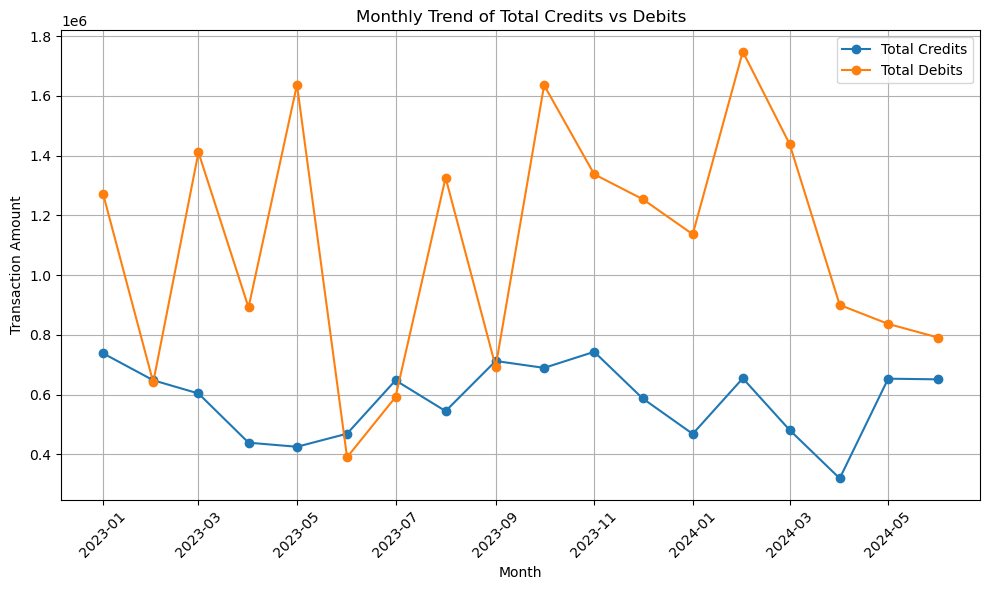

In [45]:
# Plot trends in total credits vs. debits over time
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary["Month"],
    monthly_summary["CreditAmount"],
    label="Total Credits",
    marker="o"
)

plt.plot(
    monthly_summary["Month"],
    monthly_summary["DebitAmount"],
    label="Total Debits",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.title("Monthly Trend of Total Credits vs Debits")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


In [46]:
# Export cleaned dataset to Excel
with pd.ExcelWriter("Task_2_Transaction_Analysis.xlsx") as writer:
    monthly_summary.to_excel(writer, sheet_name="Monthly Summary", index=False)
    yearly_summary.to_excel(writer, sheet_name="Yearly Summary", index=False)
    top_accounts.to_excel(writer, sheet_name="Top Accounts", index=False)
    bottom_accounts.to_excel(writer, sheet_name="Bottom Accounts", index=False)
    dormant_summary.to_excel(writer, sheet_name="Dormant Summary", index=False)

## Task 3

---

In [47]:
# Task 3: Customer Profile Building 
# Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings. 
# Segment customers by average balance and transaction volume. 
# Create profiles for: 
# High-net inflow accounts 
# High-frequency low-balance accounts 
# Accounts with negative or near-zero balances 

In [48]:
import pandas as pd

goldman_df = pd.read_excel("Task_1_Data_Cleaning.xlsx")

In [49]:
# View first few rows
goldman_df.head()

# Check column names, data types, and nulls
goldman_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [50]:
# Convert TransactionType to lowercase string and remove spaces
goldman_df["TransactionType"] = (
    goldman_df["TransactionType"]
    .astype(str)      # ensures no category/object issues
    .str.lower()      # removes case sensitivity
    .str.strip()      # removes leading/trailing spaces
)


In [51]:
# Function to classify transaction types into credit or debit
def normalize_transaction_type(x):
    """
    Classifies transaction descriptions into credit or debit
    based on keyword presence.
    """
    
    credit_keywords = [
        "deposit", "credit", "salary", "interest", "refund", "received"
    ]
    
    debit_keywords = [
        "withdraw", "withdrawal", "payment", "transfer",
        "purchase", "debit"
    ]
    
    # If any credit-related keyword is found → credit
    if any(word in x for word in credit_keywords):
        return "credit"
    
    # If any debit-related keyword is found → debit
    elif any(word in x for word in debit_keywords):
        return "debit"
    
    # If nothing matches → unknown (explicit, not hidden)
    else:
        return "unknown"


In [52]:
# Apply the normalization function to TransactionType column
goldman_df["TransactionType"] = goldman_df["TransactionType"].apply(
    normalize_transaction_type
)


In [53]:
# Check final distribution of transaction types
goldman_df["TransactionType"].value_counts()


TransactionType
debit     601
credit    199
Name: count, dtype: int64

In [54]:
# Initialize credit and debit columns with zero
goldman_df["CreditAmount"] = 0.0
goldman_df["DebitAmount"] = 0.0

# Assign transaction amount to CreditAmount for credit transactions
goldman_df.loc[
    goldman_df["TransactionType"] == "credit",
    "CreditAmount"
] = goldman_df["TransactionAmount"]

# Assign transaction amount to DebitAmount for debit transactions
goldman_df.loc[
    goldman_df["TransactionType"] == "debit",
    "DebitAmount"
] = goldman_df["TransactionAmount"]


In [55]:
# validation
goldman_df[
    ["TransactionType", "TransactionAmount", "CreditAmount", "DebitAmount"]
].head(10)


,TransactionType,TransactionAmount,CreditAmount,DebitAmount
0,debit,87480.05448,0.00000,87480.05448
1,debit,20315.74505,0.00000,20315.74505
2,credit,10484.57165,10484.57165,0.00000
3,debit,45122.27373,0.00000,45122.27373
4,debit,42360.79878,0.00000,42360.79878
5,credit,68914.59783,68914.59783,0.00000
6,credit,47538.12665,47538.12665,0.00000
7,debit,51935.49405,0.00000,51935.49405
8,debit,67602.35218,0.00000,67602.35218
9,credit,35930.46511,35930.46511,0.00000


In [56]:
# Count number of transactions per account
# Transaction frequency shows customer engagement level
transaction_frequency = (
    goldman_df
    .groupby("AccountID")
    .size()
    .reset_index(name="TransactionCount")
)


In [57]:
# validation
transaction_frequency.head()


,AccountID,TransactionCount
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3


In [58]:
# calculate financial matrics per account,(what is needed-total credit, total debit, net inflow, average balance
# Aggregate financial metrics per account
financial_summary = (
    goldman_df
    .groupby("AccountID")
    .agg(
        TotalCredits=("CreditAmount", "sum"),
        TotalDebits=("DebitAmount", "sum"),
        AvgBalance=("AccountBalance", "mean")
    )
    .reset_index()
)

# Calculate net inflow
financial_summary["NetInflow"] = (
    financial_summary["TotalCredits"] - financial_summary["TotalDebits"]
)


In [59]:
# validation
financial_summary.head()


,AccountID,TotalCredits,TotalDebits,AvgBalance,NetInflow
0,ACC10117,142170.20378,57310.763650,70107.007957,84859.440130
1,ACC10996,62580.86356,188158.687390,43568.008084,-125577.823830
2,ACC11062,0.00000,4014.264900,38137.132610,-4014.264900
3,ACC11188,45748.34156,211828.262030,69652.151044,-166079.920470
4,ACC11285,0.00000,96729.609841,97401.348560,-96729.609841


In [60]:
# Merge transaction frequency with financial summary
customer_profile = pd.merge(
    transaction_frequency,
    financial_summary,
    on="AccountID",
    how="inner"
)


In [61]:
# validation
customer_profile.head() #confirms one row per account


,AccountID,TransactionCount,TotalCredits,TotalDebits,AvgBalance,NetInflow
0,ACC10117,4,142170.20378,57310.763650,70107.007957,84859.440130
1,ACC10996,5,62580.86356,188158.687390,43568.008084,-125577.823830
2,ACC11062,2,0.00000,4014.264900,38137.132610,-4014.264900
3,ACC11188,5,45748.34156,211828.262030,69652.151044,-166079.920470
4,ACC11285,3,0.00000,96729.609841,97401.348560,-96729.609841


In [62]:
# calculate highest transaction frequency to set upper limit for rubric
highest_transaction_frequency = customer_profile["TransactionCount"].max()
# validation
highest_transaction_frequency


14

In [63]:
# activity level rubric for high >8 transx, med 4-8 transx, low<4 transx
# Function to classify activity level based on transaction count
def activity_level(count):
    if count > 8:
        return "High" 
    elif 4 <= count <= 8:
        return "Medium"
    else:
        return "Low"

# Apply activity level classification
customer_profile["ActivityLevel"] = (
    customer_profile["TransactionCount"].apply(activity_level)
)


In [64]:
# validation
customer_profile["ActivityLevel"].value_counts()


ActivityLevel
Medium    109
Low        79
High        6
Name: count, dtype: int64

In [65]:
# Function to segment customers by average balance
def balance_segment(balance):
    if balance > 80000:
        return "High Balance"
    elif 30000 <= balance <= 80000:
        return "Medium Balance"
    else:
        return "Low Balance"

# Apply balance segmentation
customer_profile["BalanceSegment"] = (
    customer_profile["AvgBalance"].apply(balance_segment)
)


In [66]:
customer_profile["BalanceSegment"].value_counts()


BalanceSegment
Medium Balance    127
High Balance       65
Low Balance         2
Name: count, dtype: int64

In [67]:
high_net_inflow = customer_profile[
    customer_profile["NetInflow"] >
    customer_profile["NetInflow"].quantile(0.75)
]


In [68]:
high_net_inflow.shape

(49, 8)

In [69]:
high_net_inflow.head()


,AccountID,TransactionCount,TotalCredits,TotalDebits,AvgBalance,NetInflow,ActivityLevel,BalanceSegment
0,ACC10117,4,142170.20378,57310.76365,70107.007957,84859.44013,Medium,Medium Balance
2,ACC11062,2,0.00000,4014.26490,38137.132610,-4014.26490,Low,Medium Balance
7,ACC12334,6,149116.79761,161110.49208,78082.517883,-11993.69447,Medium,Medium Balance
10,ACC15359,3,122856.48300,120413.19788,118477.129717,2443.28512,Low,High Balance
17,ACC18140,2,45680.91092,38542.74767,39960.076965,7138.16325,Low,Medium Balance


In [70]:
high_freq_low_balance = customer_profile[
    (customer_profile["ActivityLevel"] == "High") &
    (customer_profile["BalanceSegment"] == "Low Balance")
]



In [71]:
high_freq_low_balance.shape



(0, 8)

In [72]:
low_balance_accounts = customer_profile[
    customer_profile["AvgBalance"] <= 30000
]

In [73]:
low_balance_accounts.head()


,AccountID,TransactionCount,TotalCredits,TotalDebits,AvgBalance,NetInflow,ActivityLevel,BalanceSegment
20,ACC19178,1,64100.78213,0.00000,-1541.176812,64100.78213,Low,Low Balance
163,ACC83005,3,94843.58251,155963.09449,25651.786935,-61119.51198,Low,Low Balance


In [74]:
with pd.ExcelWriter("Task_3_Customer_Profiles.xlsx") as writer:
    customer_profile.to_excel(writer, sheet_name="All Profiles", index=False)
    high_net_inflow.to_excel(writer, sheet_name="High Net Inflow", index=False)
    high_freq_low_balance.to_excel(writer, sheet_name="High Freq Low Balance", index=False)
    low_balance_accounts.to_excel(writer, sheet_name="Low Balance Accounts", index=False)


## Task 4

---

In [75]:
#  Task 4: Financial Risk Identification (10 Marks) 
# Track accounts with frequent large withdrawals or overdrafts. 
# Calculate balance volatility using standard deviation or coefficient of variation. 
# Use IQR or z-score methods to detect anomalies. 
# Highlight customers with irregular or suspicious transaction behavior. 

In [76]:
import pandas as pd
import numpy as np

# Load cleaned data from Task 1
goldman_df = pd.read_excel("Task_1_Data_Cleaning.xlsx")


In [77]:
goldman_df.head()
goldman_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [78]:
goldman_df["TransactionType"] = (
    goldman_df["TransactionType"]
    .astype(str)
    .str.lower()
    .str.strip()
)


In [79]:
# Function to classify transaction types into credit or debit
def normalize_transaction_type(x):
    credit_keywords = ["deposit", "credit", "salary", "interest", "refund", "received"]
    debit_keywords = ["withdraw", "withdrawal", "payment", "transfer", "purchase", "debit"]

    if any(word in x for word in credit_keywords):
        return "credit"
    elif any(word in x for word in debit_keywords):
        return "debit"
    else:
        return "unknown"


In [80]:
# Apply the normalization function to TransactionType column
goldman_df["TransactionType"] = goldman_df["TransactionType"].apply(
    normalize_transaction_type
)


In [81]:
# Apply the normalization function to TransactionType column
goldman_df["TransactionType"] = goldman_df["TransactionType"].apply(
    normalize_transaction_type
)


In [82]:
# Check final distribution of transaction types
goldman_df["TransactionType"].value_counts()

TransactionType
debit     601
credit    199
Name: count, dtype: int64

In [83]:
# identifying frequent large withdrawals
large_withdrawal_threshold = goldman_df.loc[
    goldman_df["TransactionType"] == "debit",
    "TransactionAmount"
].quantile(0.75) # using 75% of debit transaction


In [84]:
# validation
large_withdrawal_threshold.round(2)


np.float64(71891.27)

In [85]:
# flag large withdrawal
goldman_df["LargeWithdrawalFlag"] = (
    (goldman_df["TransactionType"] == "debit") &
    (goldman_df["TransactionAmount"] >= large_withdrawal_threshold)
)

#validation
goldman_df["LargeWithdrawalFlag"].value_counts()


LargeWithdrawalFlag
False    649
True     151
Name: count, dtype: int64

In [86]:
# identifying accounts with frequent large withdrawals
large_withdrawal_accounts = (
    goldman_df[goldman_df["LargeWithdrawalFlag"]]
    .groupby("AccountID")
    .size()
    .reset_index(name="LargeWithdrawalCount")
)
# validation
large_withdrawal_accounts.head()


,AccountID,LargeWithdrawalCount
0,ACC12334,1
1,ACC13357,3
2,ACC15228,1
3,ACC15359,1
4,ACC15671,1


In [87]:
# calculating balance volatility per account
balance_volatility = (
    goldman_df
    .groupby("AccountID")["AccountBalance"]
    .agg(
        MeanBalance="mean",
        StdBalance="std"
    )
    .reset_index()
)


In [88]:
# calculating coefficient of varitaion
balance_volatility["BalanceCV"] = (
    balance_volatility["StdBalance"] /
    balance_volatility["MeanBalance"].replace(0, np.nan)
)
# validation
balance_volatility.head()
balance_volatility.round(2)


,AccountID,MeanBalance,StdBalance,BalanceCV
0,ACC10117,70107.01,25886.97,0.37
1,ACC10996,43568.01,9434.00,0.22
2,ACC11062,38137.13,3208.74,0.08
3,ACC11188,69652.15,35494.66,0.51
4,ACC11285,97401.35,55922.73,0.57
...,...,...,...,...
189,ACC97225,38652.31,28069.59,0.73
190,ACC97411,55978.32,7871.68,0.14
191,ACC99117,47228.19,20780.58,0.44
192,ACC99409,83743.92,21429.76,0.26


In [89]:
# detecting anomalies using IQR
# calculate IQR bounds
Q1 = goldman_df["TransactionAmount"].quantile(0.25)
Q3 = goldman_df["TransactionAmount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# validation
Q1.round(2), Q3.round(2), lower_bound.round(2), upper_bound.round(2)


(np.float64(31692.0),
 np.float64(71913.39),
 np.float64(-28640.08),
 np.float64(132245.48))

In [90]:
# flagging anomalous transactions
goldman_df["AnomalyFlag"] = (
    (goldman_df["TransactionAmount"] < lower_bound) |
    (goldman_df["TransactionAmount"] > upper_bound)
)
#validation
goldman_df["AnomalyFlag"].value_counts()


AnomalyFlag
False    799
True       1
Name: count, dtype: int64

In [91]:
# identifying accounts with anomalies
anomaly_accounts = (
    goldman_df[goldman_df["AnomalyFlag"]]
    .groupby("AccountID")
    .size()
    .reset_index(name="AnomalyCount")
)
# validation
anomaly_accounts.head()


,AccountID,AnomalyCount
0,ACC21719,1


In [92]:
# combining risk indiactor into one risk table
risk_profile = balance_volatility.merge(
    large_withdrawal_accounts,
    on="AccountID",
    how="left"
).merge(
    anomaly_accounts,
    on="AccountID",
    how="left"
)


In [93]:
# filling missing count with 0
risk_profile[[
    "LargeWithdrawalCount",
    "AnomalyCount"
]] = risk_profile[[
    "LargeWithdrawalCount",
    "AnomalyCount"
]].fillna(0)
# validation
risk_profile.sample(10)



,AccountID,MeanBalance,StdBalance,BalanceCV,LargeWithdrawalCount,AnomalyCount
78,ACC42467,66952.873982,30368.458558,0.453580,3.0,0.0
145,ACC76549,75949.374957,55143.675799,0.726058,0.0,0.0
86,ACC45951,54784.094947,38375.401299,0.700484,0.0,0.0
70,ACC39161,57915.391277,24399.961907,0.421304,1.0,0.0
50,ACC29477,34047.753303,53336.382019,1.566517,0.0,0.0
155,ACC78589,59110.034406,34018.743179,0.575516,0.0,0.0
165,ACC83581,73935.649112,43702.668446,0.591091,2.0,0.0
160,ACC82381,101169.278032,22938.267714,0.226732,2.0,0.0
43,ACC28295,79114.176982,25697.235084,0.324812,1.0,0.0
51,ACC29646,65702.290020,NaN,NaN,0.0,0.0


In [94]:
# flagging high risk accounts
risk_profile["HighRiskFlag"] = (
    (risk_profile["BalanceCV"] > 1) |
    (risk_profile["LargeWithdrawalCount"] >= 3) |
    (risk_profile["AnomalyCount"] >= 2)
)
# validation
risk_profile["HighRiskFlag"].value_counts()


HighRiskFlag
False    177
True      17
Name: count, dtype: int64

In [95]:
risk_profile.sample(5)

,AccountID,MeanBalance,StdBalance,BalanceCV,LargeWithdrawalCount,AnomalyCount,HighRiskFlag
149,ACC77592,45878.133823,31637.132379,0.689591,1.0,0.0,False
145,ACC76549,75949.374957,55143.675799,0.726058,0.0,0.0,False
147,ACC76699,99242.827270,8903.342345,0.089713,0.0,0.0,False
7,ACC12334,78082.517883,29362.190510,0.376041,1.0,0.0,False
106,ACC52650,53381.109303,28769.482582,0.538945,1.0,0.0,False


In [96]:
with pd.ExcelWriter("Task_4_Financial_Risk_Analysis.xlsx") as writer:
    risk_profile.to_excel(writer, sheet_name="Risk Profile", index=False)
    large_withdrawal_accounts.to_excel(writer, sheet_name="Large Withdrawals", index=False)
    anomaly_accounts.to_excel(writer, sheet_name="Anomalies", index=False)


## Task 5

---

In [97]:
# Task 5: Visualisation  
# Conduct extensive exploratory data analysis with attractive visualizations for your findings 

In [98]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")


In [99]:
# Load cleaned dataset from Task 1
goldman_df = pd.read_excel("Task_1_Data_Cleaning.xlsx")


In [100]:
goldman_df.head()
goldman_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [101]:
# Clean transaction type text
goldman_df["TransactionType"] = (
    goldman_df["TransactionType"]
    .astype(str)
    .str.lower()
    .str.strip()
)


In [102]:
# Rule-based classification
def normalize_transaction_type(x):
    credit_keywords = ["deposit", "credit", "salary", "interest", "refund", "received"]
    debit_keywords = ["withdraw", "withdrawal", "payment", "transfer", "purchase", "debit"]
    
    if any(word in x for word in credit_keywords):
        return "credit"
    elif any(word in x for word in debit_keywords):
        return "debit"
    else:
        return "unknown"

goldman_df["TransactionType"] = goldman_df["TransactionType"].apply(normalize_transaction_type)
# validation
goldman_df["TransactionType"].value_counts()



TransactionType
debit     601
credit    199
Name: count, dtype: int64

In [103]:
# Initialize columns
goldman_df["CreditAmount"] = 0.0
goldman_df["DebitAmount"] = 0.0

# Assign values
goldman_df.loc[goldman_df["TransactionType"] == "credit", "CreditAmount"] = goldman_df["TransactionAmount"]
goldman_df.loc[goldman_df["TransactionType"] == "debit", "DebitAmount"] = goldman_df["TransactionAmount"]

# validation
goldman_df[["TransactionType", "TransactionAmount", "CreditAmount", "DebitAmount"]].head()


,TransactionType,TransactionAmount,CreditAmount,DebitAmount
0,debit,87480.05448,0.00000,87480.05448
1,debit,20315.74505,0.00000,20315.74505
2,credit,10484.57165,10484.57165,0.00000
3,debit,45122.27373,0.00000,45122.27373
4,debit,42360.79878,0.00000,42360.79878


In [104]:
# create time variable for trends
# Extract year and month
goldman_df["Year"] = goldman_df["TransactionDate"].dt.year
goldman_df["Month"] = goldman_df["TransactionDate"].dt.to_period("M")

# validation
goldman_df[["TransactionDate", "Year", "Month"]].head()


,TransactionDate,Year,Month
0,2023-10-21,2023,2023-10
1,2023-06-20,2023,2023-06
2,2023-01-02,2023,2023-01
3,2023-07-25,2023,2023-07
4,2023-07-25,2023,2023-07


In [105]:
# visual 1- monthly credit vs debit trends
# Shows cash inflow vs outflow trends
# Identifies spending-heavy or deposit-heavy periods
# Prepare monthly summary
monthly_summary = (
    goldman_df
    .groupby("Month")[["CreditAmount", "DebitAmount"]]
    .sum()
    .reset_index()
)

# Convert Month to datetime for plotting
monthly_summary["Month"] = monthly_summary["Month"].astype(str)
monthly_summary["Month"] = pd.to_datetime(monthly_summary["Month"])

# validation
monthly_summary.head()

,Month,CreditAmount,DebitAmount
0,2023-01-01,738270.104450,2.318376e+06
1,2023-02-01,648261.004850,1.433853e+06
2,2023-03-01,604002.422140,2.027793e+06
3,2023-04-01,439321.687687,1.338294e+06
4,2023-05-01,425589.871840,2.203715e+06


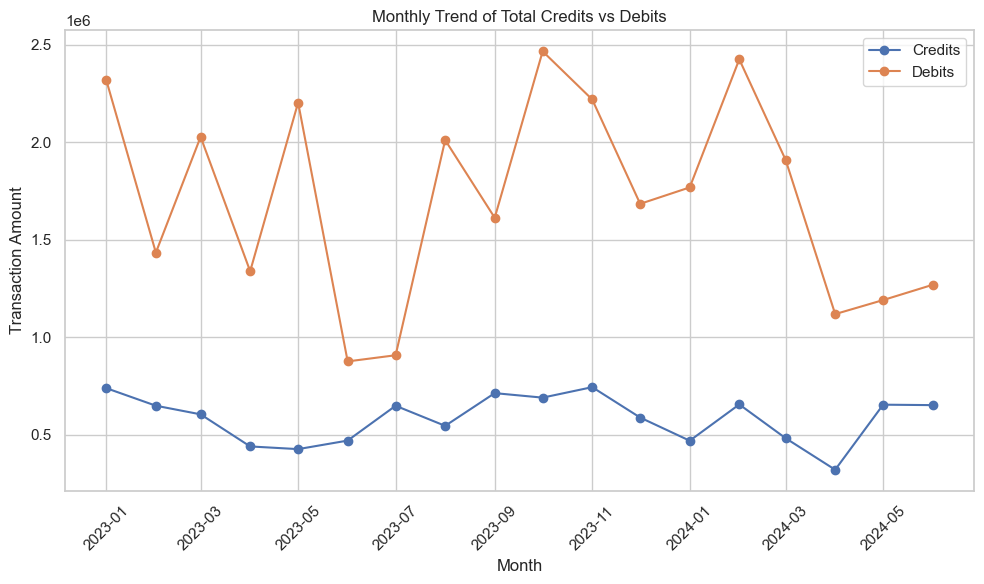

In [106]:
# Plot credit vs debit trend
plt.figure(figsize=(10, 6))

plt.plot(monthly_summary["Month"], monthly_summary["CreditAmount"], label="Credits", marker="o")
plt.plot(monthly_summary["Month"], monthly_summary["DebitAmount"], label="Debits", marker="o")

plt.title("Monthly Trend of Total Credits vs Debits")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [107]:
# visual 2- transaction type distribution
# Shows proportion of inflows vs outflows
# Count transaction types
txn_type_counts = goldman_df["TransactionType"].value_counts()


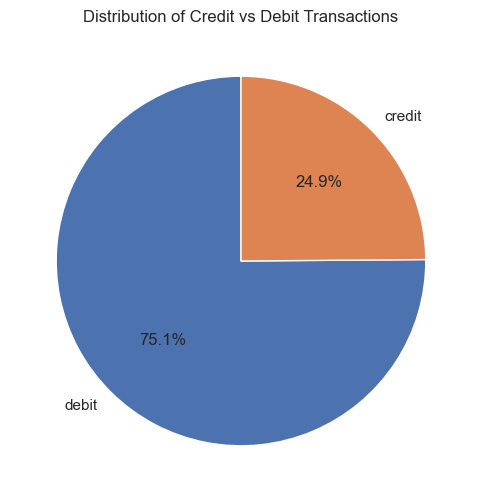

In [108]:
# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(txn_type_counts, labels=txn_type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Credit vs Debit Transactions")
plt.show()


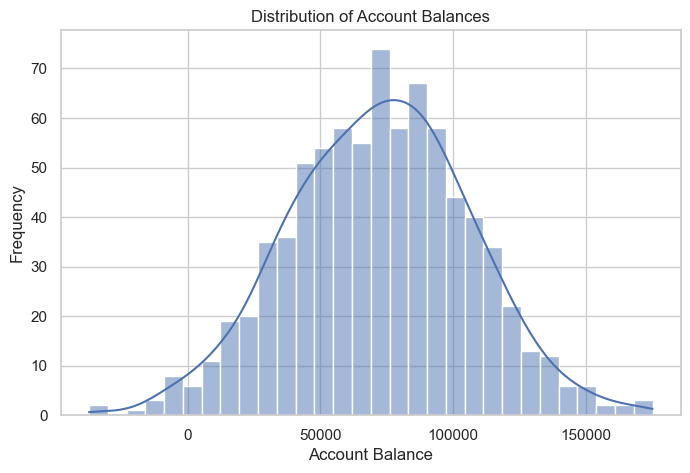

In [109]:
# distribution of account balances
# identifies skewness
# Highlights risky low-balance accounts
plt.figure(figsize=(8, 5))
sns.histplot(goldman_df["AccountBalance"], bins=30, kde=True)
plt.title("Distribution of Account Balances")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")
plt.show()


In [110]:
# activity level distribution
# Shows how active customers are
# Calculate transaction frequency per account
transaction_frequency = (
    goldman_df
    .groupby("AccountID")
    .size()
    .reset_index(name="TransactionCount")
)


In [111]:
# Define activity level
def activity_level(count):
    if count > 8:
        return "High"
    elif 4 <= count <= 8:
        return "Medium"
    else:
        return "Low"

transaction_frequency["ActivityLevel"] = transaction_frequency["TransactionCount"].apply(activity_level)


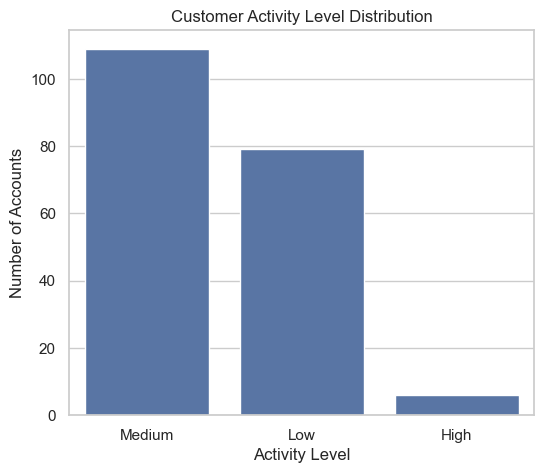

In [112]:
# Plot activity levels
plt.figure(figsize=(6, 5))
sns.countplot(x="ActivityLevel", data=transaction_frequency)
plt.title("Customer Activity Level Distribution")
plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")
plt.show()


In [113]:
import pandas as pd

risk_profile = pd.read_excel("Task_4_Financial_Risk_Analysis.xlsx", sheet_name="Risk Profile")


In [114]:
# Flagging high-risk accounts based on selected risk indicators
risk_profile["HighRiskFlag"] = (
    (risk_profile["BalanceCV"] > 1) |
    (risk_profile["LargeWithdrawalCount"] >= 3) |
    (risk_profile["AnomalyCount"] >= 2)
)
# validaton
risk_profile["HighRiskFlag"].value_counts()


HighRiskFlag
False    177
True      17
Name: count, dtype: int64

In [115]:
risk_profile["HighRiskFlag"].value_counts(normalize=True) * 100


HighRiskFlag
False    91.237113
True      8.762887
Name: proportion, dtype: float64

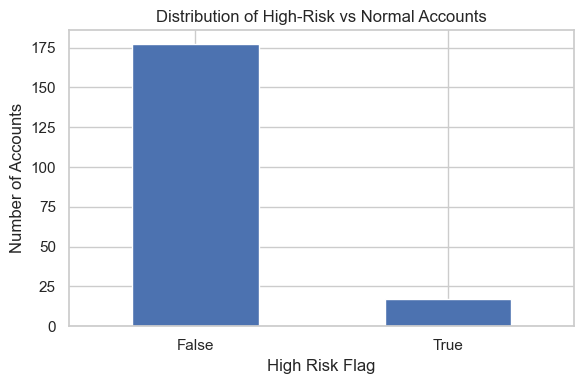

In [116]:
import matplotlib.pyplot as plt

risk_counts = risk_profile["HighRiskFlag"].value_counts()

plt.figure(figsize=(6, 4))
risk_counts.plot(kind="bar")

plt.title("Distribution of High-Risk vs Normal Accounts")
plt.xlabel("High Risk Flag")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Task 6

---

In [117]:
# Task 6: Hypothesis Testing
# Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts. 
# Conduct hypothesis testing based on segmentation.

In [118]:
# Core libraries
import pandas as pd
import numpy as np

# Statistical testing
from scipy import stats


In [119]:
# Load cleaned dataset from Task 1
goldman_df = pd.read_excel("Task_1_Data_Cleaning.xlsx")


In [120]:
goldman_df.head()
goldman_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [121]:
# Clean transaction type text
goldman_df["TransactionType"] = (
    goldman_df["TransactionType"]
    .astype(str)
    .str.lower()
    .str.strip()
)


In [122]:
# Rule-based transaction classification
def normalize_transaction_type(x):
    credit_keywords = ["deposit", "credit", "salary", "interest", "refund", "received"]
    debit_keywords = ["withdraw", "withdrawal", "payment", "transfer", "purchase", "debit"]

    if any(word in x for word in credit_keywords):
        return "credit"
    elif any(word in x for word in debit_keywords):
        return "debit"
    else:
        return "unknown"

goldman_df["TransactionType"] = goldman_df["TransactionType"].apply(normalize_transaction_type)
#validation
goldman_df["TransactionType"].value_counts()



TransactionType
debit     601
credit    199
Name: count, dtype: int64

In [123]:
# building customer level matrics
# transx frequency per account
# Count number of transactions per account
transaction_frequency = (
    goldman_df
    .groupby("AccountID")
    .size()
    .reset_index(name="TransactionCount")
)
# validation
transaction_frequency.describe()


,TransactionCount
count,194.000000
mean,4.123711
std,2.094937
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,14.000000


In [124]:
# Calculate average balance per account
avg_balance = (
    goldman_df
    .groupby("AccountID")["AccountBalance"]
    .mean()
    .reset_index(name="AvgBalance")
)
# validation
avg_balance.describe()


,AvgBalance
count,194.000000
mean,71995.188199
std,19687.696560
min,-1541.176812
25%,59617.342346
50%,72044.730778
75%,84123.694741
max,128085.501000


In [125]:
# Merge frequency and balance data
customer_profile = pd.merge(
    transaction_frequency,
    avg_balance,
    on="AccountID",
    how="inner"
)
customer_profile.shape


(194, 3)

In [126]:
customer_profile.head()


,AccountID,TransactionCount,AvgBalance
0,ACC10117,4,70107.007957
1,ACC10996,5,43568.008084
2,ACC11062,2,38137.132610
3,ACC11188,5,69652.151044
4,ACC11285,3,97401.348560


In [127]:
# Null Hypothesis (H₀)
# High-volume transaction accounts do not have higher average balances than low-volume accounts.
# Alternative Hypothesis (H₁)
# High-volume transaction accounts have higher average balances than low-volume accounts.

# Define transaction volume threshold (median split)
volume_threshold = customer_profile["TransactionCount"].median()

# validation
volume_threshold



4.0

In [128]:
# Create volume group labels
customer_profile["VolumeGroup"] = np.where(
    customer_profile["TransactionCount"] > volume_threshold,
    "High Volume",
    "Low Volume"
)
# validation
customer_profile["VolumeGroup"].value_counts()


VolumeGroup
Low Volume     121
High Volume     73
Name: count, dtype: int64

In [129]:
# extracting balance data for both the groups
# Average balances for high-volume accounts
high_volume_balances = customer_profile.loc[
    customer_profile["VolumeGroup"] == "High Volume",
    "AvgBalance"
]

# Average balances for low-volume accounts
low_volume_balances = customer_profile.loc[
    customer_profile["VolumeGroup"] == "Low Volume",
    "AvgBalance"
]
# validation
high_volume_balances.describe()
low_volume_balances.describe()


count       121.000000
mean      71683.275455
std       22394.188995
min       -1541.176812
25%       56492.898810
50%       70572.584723
75%       88690.313783
max      128085.501000
Name: AvgBalance, dtype: float64

In [130]:
# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(
    high_volume_balances,
    low_volume_balances,
    equal_var=False   # Welch’s t-test (safer)
)
# validation
t_statistic, p_value


(np.float64(0.31506769364079873), np.float64(0.7530534149746722))

In [131]:
# decision rule and interpretation
alpha = 0.05


In [132]:
# hypothesis decision
if p_value < alpha:
    decision = "Reject the null hypothesis"
else:
    decision = "Fail to reject the null hypothesis"

decision


'Fail to reject the null hypothesis'

In [133]:
# An independent samples t-test was conducted to compare average balances between high-volume and low-volume transaction accounts.The test did not find a statistically significant difference in average balances between the two groups.

In [134]:
# Save hypothesis test summary
hypothesis_summary = pd.DataFrame({
    "Metric": ["T-statistic", "P-value", "Decision"],
    "Value": [t_statistic, p_value, decision]
})

hypothesis_summary.to_excel("Task_6_Hypothesis_Testing.xlsx", index=False)
